Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete
CONFIGURATION
Processed data path: /content/drive/MyDrive/Research/SLSL_Medical_Dataset/Latest/Original/
Augmented data path: /content/drive/MyDrive/Research/SLSL_Medical_Dataset/Latest/Augmented/
Output path: /content/drive/MyDrive/Research/SLSL_Model_Data/

LOADING PROCESSED DATA
✅ Loading augmented dataset...
   Loaded 255 augmented samples


Loading features:   0%|          | 0/255 [00:00<?, ?it/s]

✅ Successfully loaded 255 feature sequences

📊 DATA SUMMARY:
   Total samples: 255
   Feature shape: (560, 468)
   Sequence length: 560 frames
   Number of classes: 10
   Augmented data: Yes
   Max sequence length: 560

📊 CLASS DISTRIBUTION
මට_දරුණු_වේදනාවක්_තියෙනවා               :   30 samples ( 11.8%)
මට_බෙහෙත්_අරන්_ගෙදර_යන්න_පුළුවන්ද        :   30 samples ( 11.8%)
මට_වෛද්‍ය_උපදෙස්_අසා_ගන්න_ඕන             :   30 samples ( 11.8%)
මම_වෛද්‍යවරයාට_ස්තූති_වෙනවා              :   30 samples ( 11.8%)
මට_දැන්_හොඳයි_වගේ_දැනෙනවා              :   25 samples (  9.8%)
මට_පරික්ෂාව_ගන්න_කාලය_දැනගන්න_ඕන         :   25 samples (  9.8%)
මට_බෙහෙත්_ගන්න_ඕනෙ                       :   25 samples (  9.8%)
මගෙ_අතේ_උණුසුම_වැඩි                     :   20 samples (  7.8%)
මගේ_අතේ_තුවාලයක්_තියෙනවා               :   20 samples (  7.8%)
මගේ_උගුර_රිදෙනවා                        :   20 samples (  7.8%)


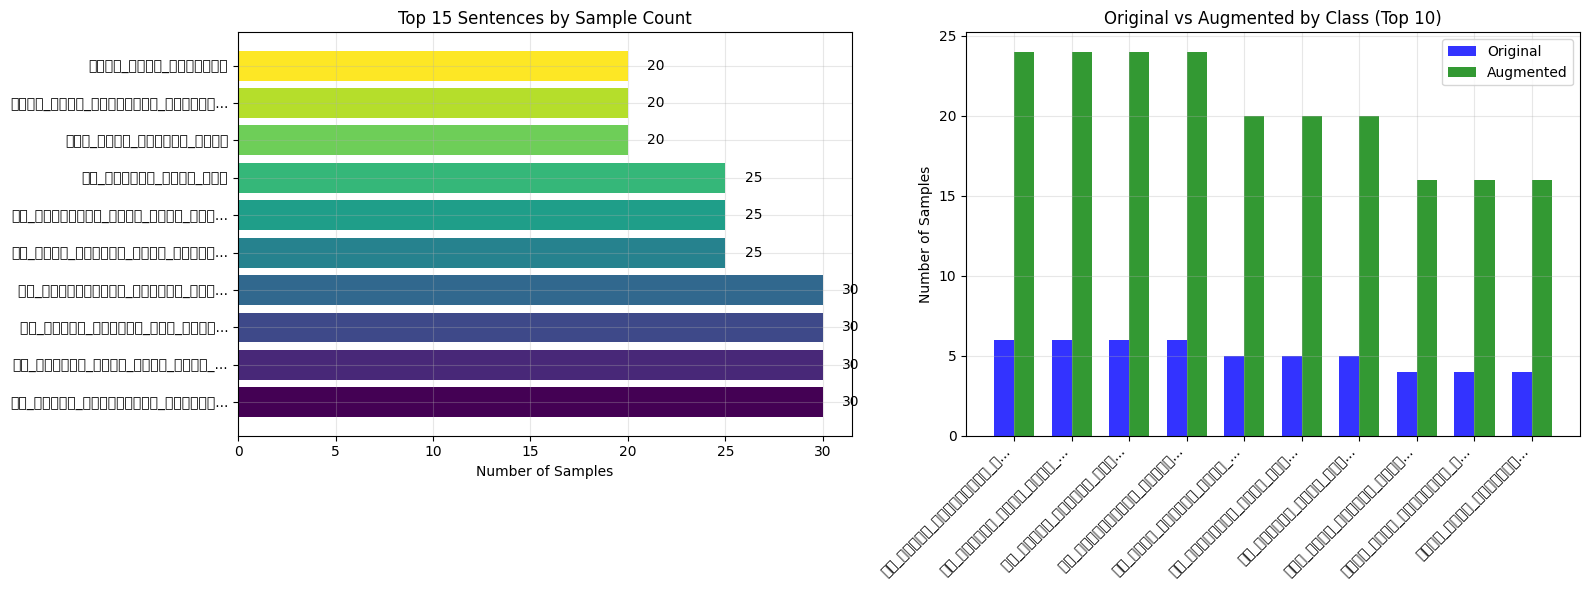


📊 Statistics:
   Total classes: 10
   Total samples: 255
   Min samples per class: 20
   Max samples per class: 30
   Avg samples per class: 25.5
   Median samples per class: 25.0

📊 Augmentation Breakdown:
   original    :     51 samples (20.0%)
   noise       :     51 samples (20.0%)
   scale       :     51 samples (20.0%)
   rotation    :     51 samples (20.0%)
   combined    :     51 samples (20.0%)

📊 SAMPLE SEQUENCE VISUALIZATION


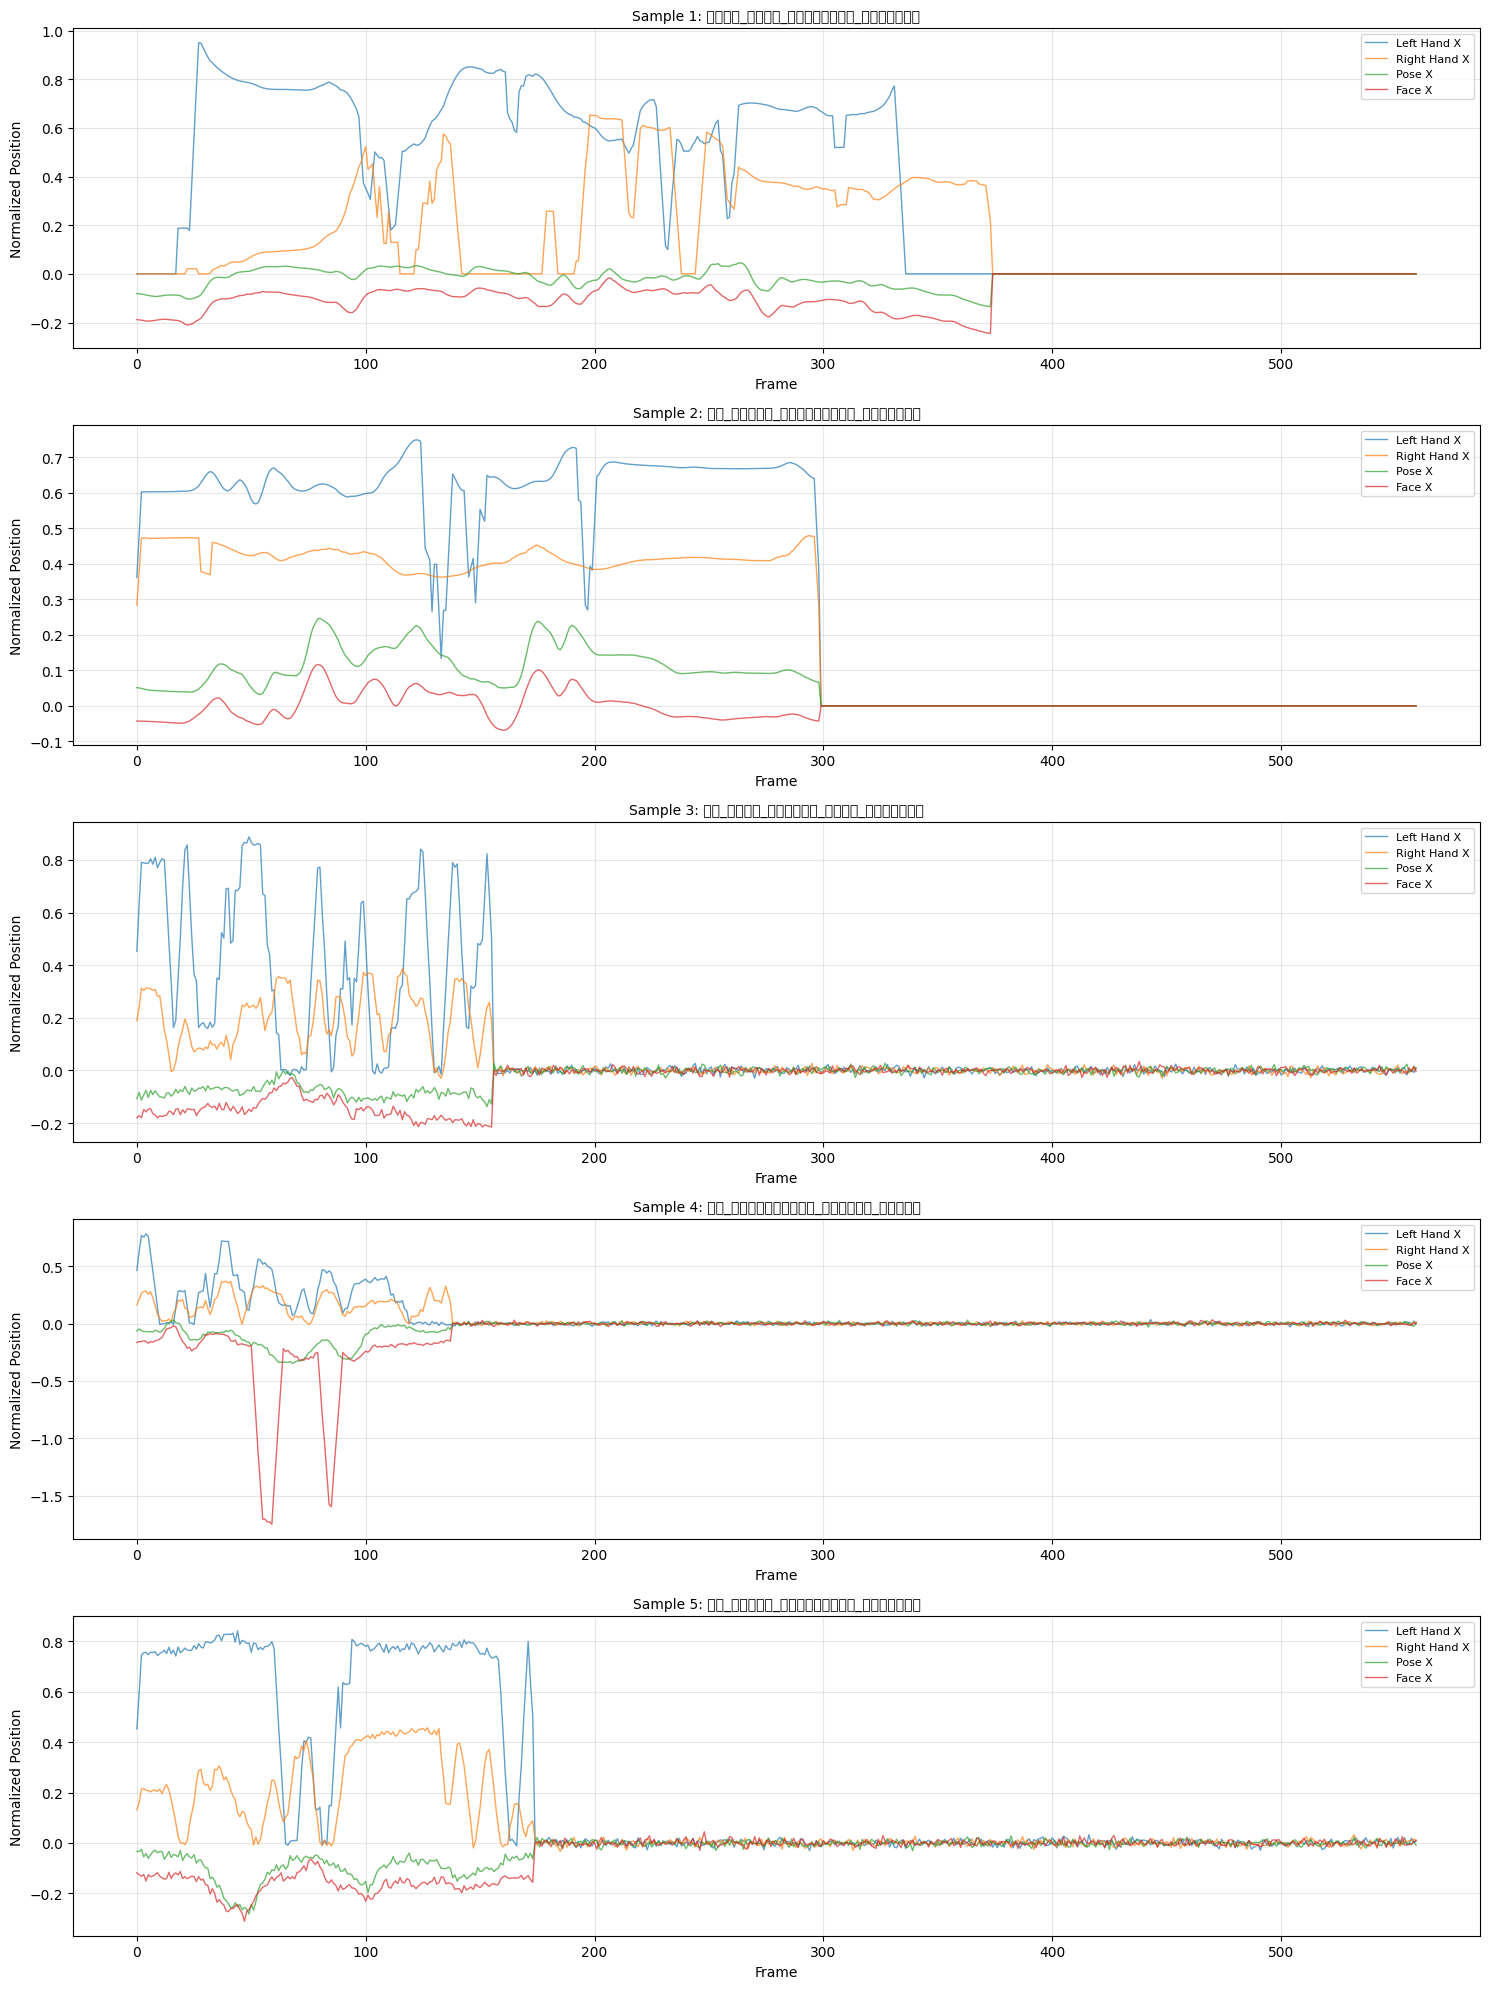

✅ Visualized 5 sample sequences

🔤 ENCODING LABELS
✅ Encoded 10 classes
   Classes: ['මගෙ_අතේ_උණුසුම_වැඩි' 'මගේ_අතේ_තුවාලයක්_තියෙනවා' 'මගේ_උගුර_රිදෙනවා'
 'මට_දරුණු_වේදනාවක්_තියෙනවා' 'මට_දැන්_හොඳයි_වගේ_දැනෙනවා'
 'මට_පරික්ෂාව_ගන්න_කාලය_දැනගන්න_ඕන' 'මට_බෙහෙත්_අරන්_ගෙදර_යන්න_පුළුවන්ද'
 'මට_බෙහෙත්_ගන්න_ඕනෙ' 'මට_වෛද්\u200dය_උපදෙස්_අසා_ගන්න_ඕන'
 'මම_වෛද්\u200dයවරයාට_ස්තූති_වෙනවා']
   Label range: 0 to 9

📊 CREATING DATA SPLITS

📊 SPLIT RESULTS:
   Training set:      165 samples (64.7%)
   Validation set:     39 samples (15.3%)
   Test set:           51 samples (20.0%)

📊 CLASS DISTRIBUTION IN SPLITS:
   Class 0 (මගෙ_අතේ_උණුසුම_වැඩි...):
      Train:  13, Val:   3, Test:   4
   Class 1 (මගේ_අතේ_තුවාලයක්_තියෙනවා...):
      Train:  13, Val:   3, Test:   4
   Class 2 (මගේ_උගුර_රිදෙනවා...):
      Train:  13, Val:   3, Test:   4
   Class 3 (මට_දරුණු_වේදනාවක්_තියෙනවා...):
      Train:  19, Val:   5, Test:   6
   Class 4 (මට_දැන්_හොඳයි_වගේ_දැනෙනවා...):
      Train:  16, Val:   4, Test: 

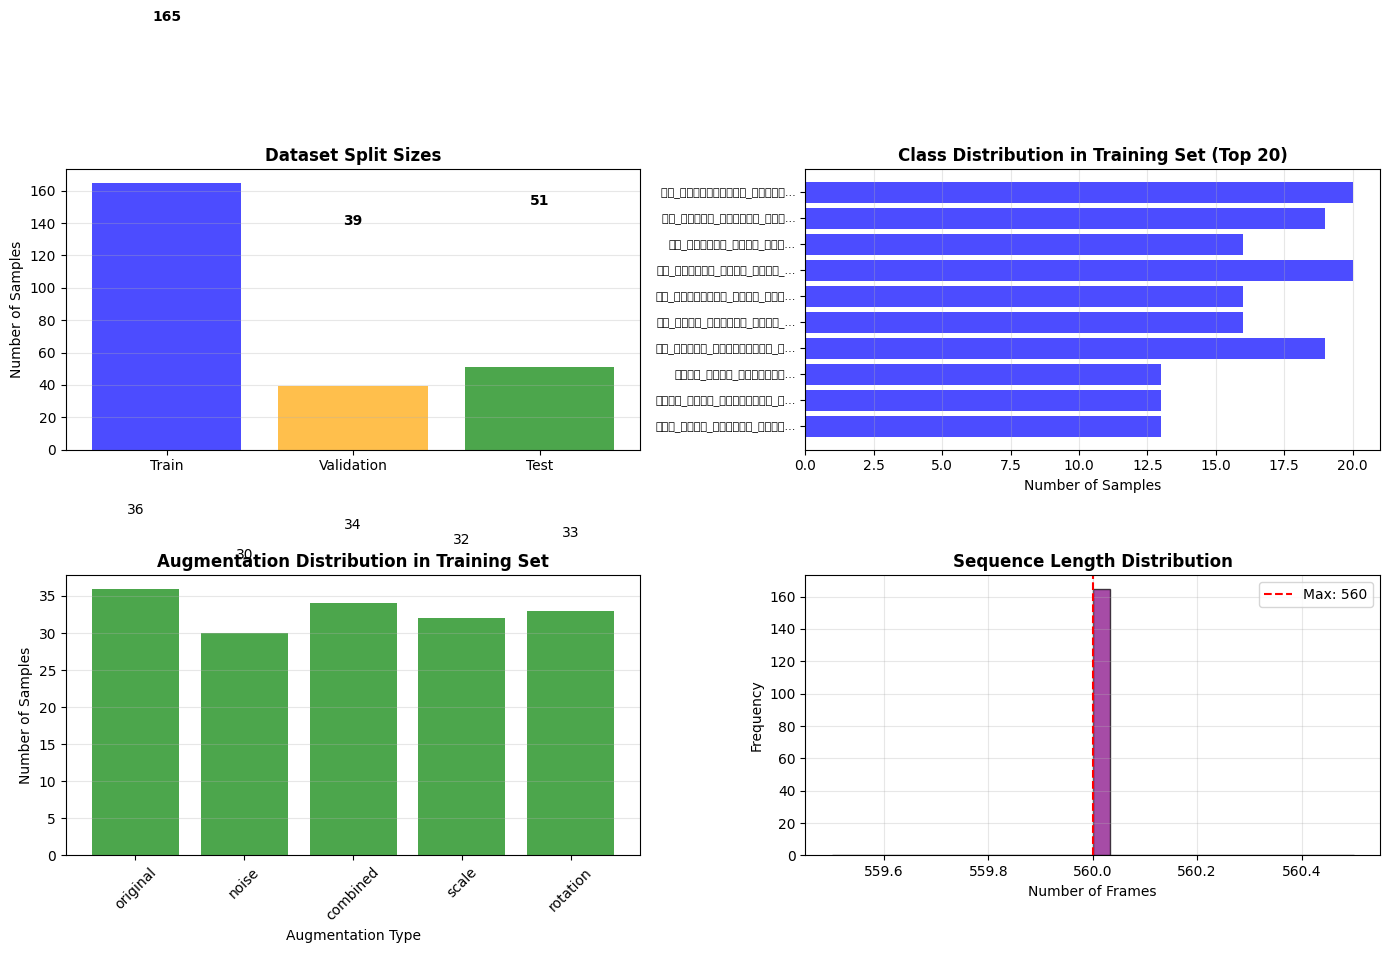

✅ Saved data preparation visualization

✅ NOTEBOOK 2 COMPLETE!

📊 FINAL SUMMARY:
   Total samples processed: 255
   Number of classes: 10
   Feature dimension: 468
   Max sequence length: 560

📊 DATA SPLITS:
   Training:   165 samples
   Validation: 39 samples
   Test:       51 samples

📁 OUTPUT LOCATION:
   /content/drive/MyDrive/Research/SLSL_Model_Data/

✨ Notebook 2 execution complete! Ready for Notebook 3 (Model Training)


In [2]:
# -*- coding: utf-8 -*-
"""SLSL_NOTEBOOK_2_MODEL_PREPARATION.ipynb

COMPLETE NOTEBOOK 2:
- Loads processed data from Notebook 1
- Analyzes class distribution with augmentation info
- Prepares train/test splits
- Creates TensorFlow datasets
- Visualizes sample sequences
"""

# ============================================
# 1. INSTALLATIONS & IMPORTS
# ============================================

!pip install tensorflow scikit-learn matplotlib seaborn numpy pandas tqdm -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

print("✅ Setup complete")

# ============================================
# 2. CONFIGURATION
# ============================================

class Config:
    # Paths from Notebook 1
    PROCESSED_PATH = "/content/drive/MyDrive/Research/SLSL_Medical_Dataset/Latest/Original/"
    AUG_PATH = "/content/drive/MyDrive/Research/SLSL_Medical_Dataset/Latest/Augmented/"
    VIZ_PATH = "/content/drive/MyDrive/Research/SLSL_Medical_Dataset/Latest/Visualization/"

    # Model parameters
    TEST_SIZE = 0.2
    VALIDATION_SIZE = 0.15  # of training data
    RANDOM_SEED = 42

    # Batch processing
    BATCH_SIZE = 32
    MAX_SEQUENCE_LENGTH = None  # Will be set from data

    # Class balancing
    USE_CLASS_WEIGHTS = True

    # Output paths
    OUTPUT_PATH = "/content/drive/MyDrive/Research/SLSL_Model_Data/"

    # Visualization
    NUM_VISUALIZATION_SAMPLES = 5

cfg = Config()

# Create output directory
os.makedirs(cfg.OUTPUT_PATH, exist_ok=True)

print("="*60)
print("CONFIGURATION")
print("="*60)
print(f"Processed data path: {cfg.PROCESSED_PATH}")
print(f"Augmented data path: {cfg.AUG_PATH}")
print(f"Output path: {cfg.OUTPUT_PATH}")
print("="*60)

# ============================================
# 3. LOAD PROCESSED DATA FROM NOTEBOOK 1
# ============================================

def load_processed_data():
    """Load the processed data from Notebook 1"""

    print("\n" + "="*60)
    print("LOADING PROCESSED DATA")
    print("="*60)

    # Try to load augmented data first (preferred)
    aug_metadata_path = os.path.join(cfg.AUG_PATH, "augmented_metadata.csv")
    aligned_metadata_path = os.path.join(cfg.PROCESSED_PATH, "aligned_metadata.csv")

    if os.path.exists(aug_metadata_path):
        print("✅ Loading augmented dataset...")
        df = pd.read_csv(aug_metadata_path)
        print(f"   Loaded {len(df)} augmented samples")

        # Load features for each sample
        features_list = []
        labels_list = []
        aug_types_list = []

        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Loading features"):
            try:
                features = np.load(row['aug_path'])
                features_list.append(features)
                labels_list.append(row['sentence'])
                aug_types_list.append(row['type'])
            except Exception as e:
                print(f"   ⚠️ Error loading {row['aug_path']}: {e}")
                continue

        print(f"✅ Successfully loaded {len(features_list)} feature sequences")

        return {
            'features': np.array(features_list, dtype=np.float32),
            'labels': np.array(labels_list),
            'aug_types': np.array(aug_types_list),
            'metadata': df,
            'is_augmented': True
        }

    elif os.path.exists(aligned_metadata_path):
        print("✅ Loading aligned dataset (no augmentation)...")
        df = pd.read_csv(aligned_metadata_path)
        print(f"   Loaded {len(df)} aligned samples")

        features_list = []
        labels_list = []

        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Loading features"):
            try:
                features = np.load(row['aligned_path'])
                features_list.append(features)
                labels_list.append(row['sentence'])
            except Exception as e:
                print(f"   ⚠️ Error loading {row['aligned_path']}: {e}")
                continue

        print(f"✅ Successfully loaded {len(features_list)} feature sequences")

        return {
            'features': np.array(features_list, dtype=np.float32),
            'labels': np.array(labels_list),
            'aug_types': np.array(['original'] * len(features_list)),
            'metadata': df,
            'is_augmented': False
        }

    else:
        print("❌ No processed data found!")
        print(f"   Checked paths:")
        print(f"   - {aug_metadata_path}")
        print(f"   - {aligned_metadata_path}")
        return None

# Load the data
data = load_processed_data()

if data is None:
    raise ValueError("Cannot proceed without processed data from Notebook 1")

# Extract data
X = data['features']
y = data['labels']
aug_types = data['aug_types']
is_augmented = data['is_augmented']

print(f"\n📊 DATA SUMMARY:")
print(f"   Total samples: {len(X)}")
print(f"   Feature shape: {X[0].shape}")
print(f"   Sequence length: {X.shape[1]} frames" if len(X.shape) > 1 else f"   Variable sequence lengths")
print(f"   Number of classes: {len(np.unique(y))}")
print(f"   Augmented data: {'Yes' if is_augmented else 'No'}")

# Set max sequence length
cfg.MAX_SEQUENCE_LENGTH = X.shape[1] if len(X.shape) > 1 else max([seq.shape[0] for seq in X])
print(f"   Max sequence length: {cfg.MAX_SEQUENCE_LENGTH}")

# ============================================
# 4. ANALYZE CLASS DISTRIBUTION (with Augmentation Info)
# ============================================

def analyze_class_distribution(labels, aug_types=None):
    """Analyze distribution of sentences with augmentation info"""

    if len(labels) == 0:
        print("❌ No labels to analyze!")
        return None

    # Count occurrences
    counter = Counter(labels)

    # Sort by frequency
    sorted_items = sorted(counter.items(), key=lambda x: x[1], reverse=True)

    print("\n" + "="*60)
    print("📊 CLASS DISTRIBUTION")
    print("="*60)

    for sentence, count in sorted_items[:20]:
        percentage = (count / len(labels)) * 100
        print(f"{sentence[:40]:40} : {count:4} samples ({percentage:5.1f}%)")

    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart - Top 15 classes
    sentences = [s[:25] + '...' if len(s) > 25 else s for s, _ in sorted_items[:15]]
    counts = [c for _, c in sorted_items[:15]]

    colors = plt.cm.viridis(np.linspace(0, 1, len(sentences)))
    axes[0].barh(range(len(sentences)), counts, color=colors)
    axes[0].set_yticks(range(len(sentences)))
    axes[0].set_yticklabels(sentences)
    axes[0].set_xlabel('Number of Samples')
    axes[0].set_title('Top 15 Sentences by Sample Count')
    axes[0].grid(True, alpha=0.3)

    # Add value labels
    for i, v in enumerate(counts):
        axes[0].text(v + 1, i, str(v), va='center')

    # Augmentation distribution if available
    if aug_types is not None:
        # Group by class and augmentation status
        class_stats = {}
        for sentence, aug_type in zip(labels, aug_types):
            if sentence not in class_stats:
                class_stats[sentence] = {'original': 0, 'augmented': 0}

            if aug_type == 'original':
                class_stats[sentence]['original'] += 1
            else:
                class_stats[sentence]['augmented'] += 1

        # Get top 10 classes
        top_classes = [s for s, _ in sorted_items[:10]]
        orig_counts = [class_stats[s]['original'] for s in top_classes]
        aug_counts = [class_stats[s]['augmented'] for s in top_classes]

        x = range(len(top_classes))
        width = 0.35

        axes[1].bar([i - width/2 for i in x], orig_counts, width, label='Original', alpha=0.8, color='blue')
        axes[1].bar([i + width/2 for i in x], aug_counts, width, label='Augmented', alpha=0.8, color='green')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels([s[:20] + '...' for s in top_classes], rotation=45, ha='right')
        axes[1].set_ylabel('Number of Samples')
        axes[1].set_title('Original vs Augmented by Class (Top 10)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_PATH, 'class_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n📊 Statistics:")
    print(f"   Total classes: {len(counter)}")
    print(f"   Total samples: {len(labels):,}")
    print(f"   Min samples per class: {min(counter.values())}")
    print(f"   Max samples per class: {max(counter.values())}")
    print(f"   Avg samples per class: {np.mean(list(counter.values())):.1f}")
    print(f"   Median samples per class: {np.median(list(counter.values())):.1f}")

    # Augmentation breakdown
    if aug_types is not None:
        print(f"\n📊 Augmentation Breakdown:")
        aug_counts = Counter(aug_types)
        for aug_type, count in aug_counts.items():
            print(f"   {aug_type:12}: {count:6} samples ({count/len(aug_types)*100:.1f}%)")

    return counter

# Analyze distribution
class_counter = analyze_class_distribution(y, aug_types)

# ============================================
# 5. VISUALIZE SAMPLE SEQUENCES
# ============================================

def visualize_sample_sequences(X, y, num_samples=5):
    """Visualize sample feature sequences"""

    print("\n" + "="*60)
    print("📊 SAMPLE SEQUENCE VISUALIZATION")
    print("="*60)

    # Select random samples
    indices = np.random.choice(len(X), min(num_samples, len(X)), replace=False)

    fig, axes = plt.subplots(num_samples, 1, figsize=(15, 4*num_samples))
    if num_samples == 1:
        axes = [axes]

    for i, idx in enumerate(indices):
        sequence = X[idx]
        label = y[idx]

        # Plot first few features
        features_to_plot = [0, 84, 168, 268]  # Left hand, Right hand, Pose, Face
        feature_names = ['Left Hand X', 'Right Hand X', 'Pose X', 'Face X']

        for feat_idx, (feat, name) in enumerate(zip(features_to_plot, feature_names)):
            if feat < sequence.shape[1]:
                axes[i].plot(sequence[:, feat], label=name, alpha=0.7, linewidth=1)

        axes[i].set_title(f"Sample {i+1}: {label}", fontsize=10)
        axes[i].set_xlabel("Frame")
        axes[i].set_ylabel("Normalized Position")
        axes[i].legend(loc='upper right', fontsize=8)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_PATH, 'sample_sequences.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"✅ Visualized {num_samples} sample sequences")

# Visualize samples
visualize_sample_sequences(X, y, cfg.NUM_VISUALIZATION_SAMPLES)

# ============================================
# 6. ENCODE LABELS
# ============================================

print("\n" + "="*60)
print("🔤 ENCODING LABELS")
print("="*60)

# Initialize label encoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Save label encoder classes
np.save(os.path.join(cfg.OUTPUT_PATH, 'classes.npy'), label_encoder.classes_)

print(f"✅ Encoded {len(label_encoder.classes_)} classes")
print(f"   Classes: {label_encoder.classes_[:10]}..." if len(label_encoder.classes_) > 10 else f"   Classes: {label_encoder.classes_}")
print(f"   Label range: {y_encoded.min()} to {y_encoded.max()}")

# ============================================
# 7. TRAIN/VALIDATION/TEST SPLIT
# ============================================

def create_stratified_split(X, y_encoded, aug_types, test_size=0.2, val_size=0.15, random_seed=42):
    """
    Create stratified train/validation/test split
    Ensures class distribution is preserved
    """

    print("\n" + "="*60)
    print("📊 CREATING DATA SPLITS")
    print("="*60)

    # First split: separate test set
    X_temp, X_test, y_temp, y_test, aug_temp, aug_test = train_test_split(
        X, y_encoded, aug_types,
        test_size=test_size,
        stratify=y_encoded,
        random_state=random_seed
    )

    # Second split: separate validation from training
    val_size_adj = val_size / (1 - test_size)  # Adjust validation size
    X_train, X_val, y_train, y_val, aug_train, aug_val = train_test_split(
        X_temp, y_temp, aug_temp,
        test_size=val_size_adj,
        stratify=y_temp,
        random_state=random_seed
    )

    print(f"\n📊 SPLIT RESULTS:")
    print(f"   Training set:   {len(X_train):6} samples ({len(X_train)/len(X)*100:.1f}%)")
    print(f"   Validation set: {len(X_val):6} samples ({len(X_val)/len(X)*100:.1f}%)")
    print(f"   Test set:       {len(X_test):6} samples ({len(X_test)/len(X)*100:.1f}%)")

    # Check class distribution in splits
    print(f"\n📊 CLASS DISTRIBUTION IN SPLITS:")
    unique_classes = np.unique(y_encoded)
    for class_idx in unique_classes[:5]:  # Show first 5 classes
        class_name = label_encoder.inverse_transform([class_idx])[0][:30]
        train_count = np.sum(y_train == class_idx)
        val_count = np.sum(y_val == class_idx)
        test_count = np.sum(y_test == class_idx)
        print(f"   Class {class_idx} ({class_name}...):")
        print(f"      Train: {train_count:3}, Val: {val_count:3}, Test: {test_count:3}")

    return {
        'X_train': X_train, 'y_train': y_train, 'aug_train': aug_train,
        'X_val': X_val, 'y_val': y_val, 'aug_val': aug_val,
        'X_test': X_test, 'y_test': y_test, 'aug_test': aug_test
    }

# Create splits
splits = create_stratified_split(
    X, y_encoded, aug_types,
    test_size=cfg.TEST_SIZE,
    val_size=cfg.VALIDATION_SIZE,
    random_seed=cfg.RANDOM_SEED
)

# ============================================
# 8. COMPUTE CLASS WEIGHTS (for imbalanced data)
# ============================================

def compute_class_weights(y_train):
    """Compute class weights to handle imbalanced data"""

    print("\n" + "="*60)
    print("⚖️ COMPUTING CLASS WEIGHTS")
    print("="*60)

    class_counts = Counter(y_train)
    total_samples = len(y_train)
    num_classes = len(class_counts)

    # Method 1: Inverse frequency
    class_weights_inv = {}
    for class_id, count in class_counts.items():
        class_weights_inv[class_id] = total_samples / (num_classes * count)

    # Method 2: Balanced weight
    class_weights_balanced = {}
    for class_id, count in class_counts.items():
        class_weights_balanced[class_id] = total_samples / (num_classes * count)
        class_weights_balanced[class_id] = class_weights_balanced[class_id] / np.max(list(class_weights_balanced.values()))

    print(f"\n📊 Class Weights (first 10 classes):")
    for class_id in sorted(class_weights_balanced.keys())[:10]:
        class_name = label_encoder.inverse_transform([class_id])[0][:30]
        count = class_counts[class_id]
        weight = class_weights_balanced[class_id]
        print(f"   Class {class_id:3} ({class_name:30}): count={count:4}, weight={weight:.3f}")

    return class_weights_balanced

if cfg.USE_CLASS_WEIGHTS:
    class_weights = compute_class_weights(splits['y_train'])
else:
    class_weights = None
    print("\n⚠️ Class weights disabled")

# ============================================
# 9. CREATE TENSORFLOW DATASETS
# ============================================

def create_tf_datasets(splits, batch_size=32):
    """Create TensorFlow datasets for efficient training"""

    print("\n" + "="*60)
    print("🔄 CREATING TENSORFLOW DATASETS")
    print("="*60)

    import tensorflow as tf

    # Convert to TensorFlow datasets
    train_dataset = tf.data.Dataset.from_tensor_slices((
        splits['X_train'],
        splits['y_train']
    ))

    val_dataset = tf.data.Dataset.from_tensor_slices((
        splits['X_val'],
        splits['y_val']
    ))

    test_dataset = tf.data.Dataset.from_tensor_slices((
        splits['X_test'],
        splits['y_test']
    ))

    # Batch and prefetch
    train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    print(f"✅ Created TensorFlow datasets")
    print(f"   Training batches: {len(splits['X_train']) // batch_size + 1}")
    print(f"   Validation batches: {len(splits['X_val']) // batch_size + 1}")
    print(f"   Test batches: {len(splits['X_test']) // batch_size + 1}")

    return train_dataset, val_dataset, test_dataset

# Create TensorFlow datasets
try:
    train_dataset, val_dataset, test_dataset = create_tf_datasets(splits, cfg.BATCH_SIZE)
    tf_datasets_created = True
except ImportError:
    print("⚠️ TensorFlow not installed. Skipping TF dataset creation.")
    tf_datasets_created = False

# ============================================
# 10. SAVE PREPARED DATA
# ============================================

def save_prepared_data(splits, label_encoder, class_weights, cfg):
    """Save all prepared data for model training"""

    print("\n" + "="*60)
    print("💾 SAVING PREPARED DATA")
    print("="*60)

    # Save numpy arrays
    np.save(os.path.join(cfg.OUTPUT_PATH, 'X_train.npy'), splits['X_train'])
    np.save(os.path.join(cfg.OUTPUT_PATH, 'y_train.npy'), splits['y_train'])
    np.save(os.path.join(cfg.OUTPUT_PATH, 'X_val.npy'), splits['X_val'])
    np.save(os.path.join(cfg.OUTPUT_PATH, 'y_val.npy'), splits['y_val'])
    np.save(os.path.join(cfg.OUTPUT_PATH, 'X_test.npy'), splits['X_test'])
    np.save(os.path.join(cfg.OUTPUT_PATH, 'y_test.npy'), splits['y_test'])

    # Save augmentation info
    np.save(os.path.join(cfg.OUTPUT_PATH, 'aug_train.npy'), splits['aug_train'])
    np.save(os.path.join(cfg.OUTPUT_PATH, 'aug_val.npy'), splits['aug_val'])
    np.save(os.path.join(cfg.OUTPUT_PATH, 'aug_test.npy'), splits['aug_test'])

    # Save class weights
    if class_weights:
        np.save(os.path.join(cfg.OUTPUT_PATH, 'class_weights.npy'), class_weights)

    # Save configuration
    config_dict = {
        'max_sequence_length': cfg.MAX_SEQUENCE_LENGTH,
        'feature_dim': splits['X_train'].shape[2] if len(splits['X_train'].shape) > 2 else splits['X_train'][0].shape[1],
        'num_classes': len(label_encoder.classes_),
        'train_samples': len(splits['X_train']),
        'val_samples': len(splits['X_val']),
        'test_samples': len(splits['X_test']),
        'batch_size': cfg.BATCH_SIZE,
        'random_seed': cfg.RANDOM_SEED
    }

    import json
    with open(os.path.join(cfg.OUTPUT_PATH, 'config.json'), 'w') as f:
        json.dump(config_dict, f, indent=2)

    print(f"✅ Saved prepared data to {cfg.OUTPUT_PATH}")
    print(f"\n📁 FILES SAVED:")
    print(f"   - X_train.npy, y_train.npy")
    print(f"   - X_val.npy, y_val.npy")
    print(f"   - X_test.npy, y_test.npy")
    print(f"   - classes.npy")
    print(f"   - config.json")

    return config_dict

# Save all prepared data
config_dict = save_prepared_data(splits, label_encoder, class_weights, cfg)

# ============================================
# 11. VISUALIZATION OF DATA PREPARATION
# ============================================

def visualize_data_preparation(splits, label_encoder):
    """Visualize the data preparation results"""

    print("\n" + "="*60)
    print("📊 DATA PREPARATION VISUALIZATION")
    print("="*60)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Dataset sizes
    sizes = [len(splits['X_train']), len(splits['X_val']), len(splits['X_test'])]
    labels = ['Train', 'Validation', 'Test']
    colors = ['blue', 'orange', 'green']

    axes[0,0].bar(labels, sizes, color=colors, alpha=0.7)
    axes[0,0].set_title('Dataset Split Sizes', fontsize=12, fontweight='bold')
    axes[0,0].set_ylabel('Number of Samples')
    axes[0,0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(sizes):
        axes[0,0].text(i, v + 100, str(v), ha='center', fontweight='bold')

    # Plot 2: Class distribution in training set
    train_class_counts = Counter(splits['y_train'])
    class_ids = sorted(train_class_counts.keys())[:20]  # First 20 classes
    class_names = [label_encoder.inverse_transform([cid])[0][:20] + '...' for cid in class_ids]
    class_counts = [train_class_counts[cid] for cid in class_ids]

    axes[0,1].barh(range(len(class_names)), class_counts, color='blue', alpha=0.7)
    axes[0,1].set_yticks(range(len(class_names)))
    axes[0,1].set_yticklabels(class_names, fontsize=8)
    axes[0,1].set_xlabel('Number of Samples')
    axes[0,1].set_title('Class Distribution in Training Set (Top 20)', fontsize=12, fontweight='bold')
    axes[0,1].grid(True, alpha=0.3, axis='x')

    # Plot 3: Augmentation distribution
    aug_counts = Counter(splits['aug_train'])
    aug_labels = list(aug_counts.keys())
    aug_values = list(aug_counts.values())

    axes[1,0].bar(aug_labels, aug_values, color='green', alpha=0.7)
    axes[1,0].set_title('Augmentation Distribution in Training Set', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('Augmentation Type')
    axes[1,0].set_ylabel('Number of Samples')
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(aug_values):
        axes[1,0].text(i, v + 10, str(v), ha='center')

    # Plot 4: Sequence length distribution
    seq_lengths = [seq.shape[0] for seq in splits['X_train'][:1000]]  # Sample first 1000
    axes[1,1].hist(seq_lengths, bins=30, color='purple', alpha=0.7, edgecolor='black')
    axes[1,1].set_title('Sequence Length Distribution', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Number of Frames')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].axvline(cfg.MAX_SEQUENCE_LENGTH, color='red', linestyle='--', label=f'Max: {cfg.MAX_SEQUENCE_LENGTH}')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_PATH, 'data_preparation_summary.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print("✅ Saved data preparation visualization")

# Create visualization
visualize_data_preparation(splits, label_encoder)

# ============================================
# 12. FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("✅ NOTEBOOK 2 COMPLETE!")
print("="*60)

print(f"\n📊 FINAL SUMMARY:")
print(f"   Total samples processed: {len(X)}")
print(f"   Number of classes: {len(label_encoder.classes_)}")
print(f"   Feature dimension: {config_dict['feature_dim']}")
print(f"   Max sequence length: {config_dict['max_sequence_length']}")
print(f"\n📊 DATA SPLITS:")
print(f"   Training:   {config_dict['train_samples']:,} samples")
print(f"   Validation: {config_dict['val_samples']:,} samples")
print(f"   Test:       {config_dict['test_samples']:,} samples")
print(f"\n📁 OUTPUT LOCATION:")
print(f"   {cfg.OUTPUT_PATH}")

# Save notebook completion marker
with open(os.path.join(cfg.OUTPUT_PATH, 'notebook2_complete.txt'), 'w') as f:
    f.write("Notebook 2 completed successfully\n")
    f.write(f"Total samples: {len(X)}\n")
    f.write(f"Classes: {len(label_encoder.classes_)}\n")
    f.write(f"Feature dim: {config_dict['feature_dim']}\n")
    f.write(f"Max sequence length: {config_dict['max_sequence_length']}\n")

print("\n✨ Notebook 2 execution complete! Ready for Notebook 3 (Model Training)")
print("="*60)